In [84]:
using GLPK, JuMP, Plots

model = Model(GLPK.Optimizer)

T = 20
N = 20
h = T/N

# Demand
d = [370, 200, 230, 270, 300, 280, 240, 210, 370, 190,
     180, 200, 0, 270, 300, 280, 240, 210, 260, 190]

# variable operating costs [€/MWh]
c = [25.0, 24.0, 45.0]

# CO2 [kg/MWh]
# s = [30.0, 40.0, 200.0]

# ramp rates [MW/time step]
k_heat = [80.0, 30.0, 100.0]
k_cool = [60.0, 40.0, 100.0]

# illustrative investment costs
# €/MW of installed capacity
investment_generator = [508.0, 525.0, 150.0]

# €/MWh storage capacity
investment_storage_energy = 20.0

# €/MW storage charging/discharging power
investment_storage_power = 30.0
eff_charge = 0.95
eff_discharge = 0.95
E_start_fraction = 0.5

# VARIABLES
# production
@variable(model, x[1:3,1:N] >= 0)

# installed generator capacities
@variable(model, m[1:3] >= 0)

# storage
@variable(model, E[1:N] >= 0)
@variable(model, charge[1:N] >= 0)
@variable(model, discharge[1:N] >= 0)

# installed storage sizes
@variable(model, E_max >= 0)
@variable(model, P_charge_max >= 0)
@variable(model, P_discharge_max >= 0)

# OBJECTIVE
@objective(model, Min,

    # operating costs
    h * sum(c[j] * x[j,t] for j=1:3, t=1:N) + sum(investment_generator[j] * m[j] for j=1:3) + investment_storage_energy * E_max + investment_storage_power * (P_charge_max + P_discharge_max))

# GENERATOR CAPACITY
@constraint(model, [j=1:3,t=1:N],x[j,t] <= m[j])

# RAMPING
@constraint(model, [j=1:3,t=2:N],x[j,t] - x[j,t-1] <= k_heat[j])
@constraint(model, [j=1:3,t=2:N],x[j,t-1] - x[j,t] <= k_cool[j])

# STORAGE POWER
@constraint(model, [t=1:N], charge[t] <= P_charge_max)
@constraint(model, [t=1:N],discharge[t] <= P_discharge_max)

# STORAGE CAPACITY
@constraint(model, [t=1:N],E[t] <= E_max)

# Start storage = 50% of installed capacity
@constraint(model,
    E[1] ==
    E_start_fraction * E_max +
    h * eff_charge * charge[1] -
    h * discharge[1] / eff_discharge
)

@constraint(model, [t=2:N],
    E[t] ==
    E[t-1] +
    h * eff_charge * charge[t] -
    h * discharge[t] / eff_discharge
)

# end storage = start storage
@constraint(model,
    E[N] == E_start_fraction * E_max
)

# =========================================================
# HEAT BALANCE
# =========================================================

@constraint(model, [t=1:N],
    sum(x[j,t] for j=1:3)
    + discharge[t]
    ==
    d[t] + charge[t]
)

# =========================================================
# SOLVE
# =========================================================

optimize!(model)

println("Status: ", termination_status(model))

println("\nOptimal generator capacities:")
println("Heat pump: ", value(m[1]), " MW")
println("Biomass:   ", value(m[2]), " MW")
println("Gas:       ", value(m[3]), " MW")

println("\nOptimal storage:")
println("Energy capacity:    ", value(E_max), " MWh")
println("Charging power:     ", value(P_charge_max), " MW")
println("Discharging power:  ", value(P_discharge_max), " MW")

println("\nTotal objective: ", objective_value(model))

Status: OPTIMAL

Optimal generator capacities:
Heat pump: 59.99999999999997 MW
Biomass:   145.74244415243103 MW
Gas:       58.935611038107766 MW

Optimal storage:
Energy capacity:    221.73041012518158 MWh
Charging power:     115.74244415243115 MW
Discharging power:  105.32194480946124 MW

Total objective: 260638.03790026973


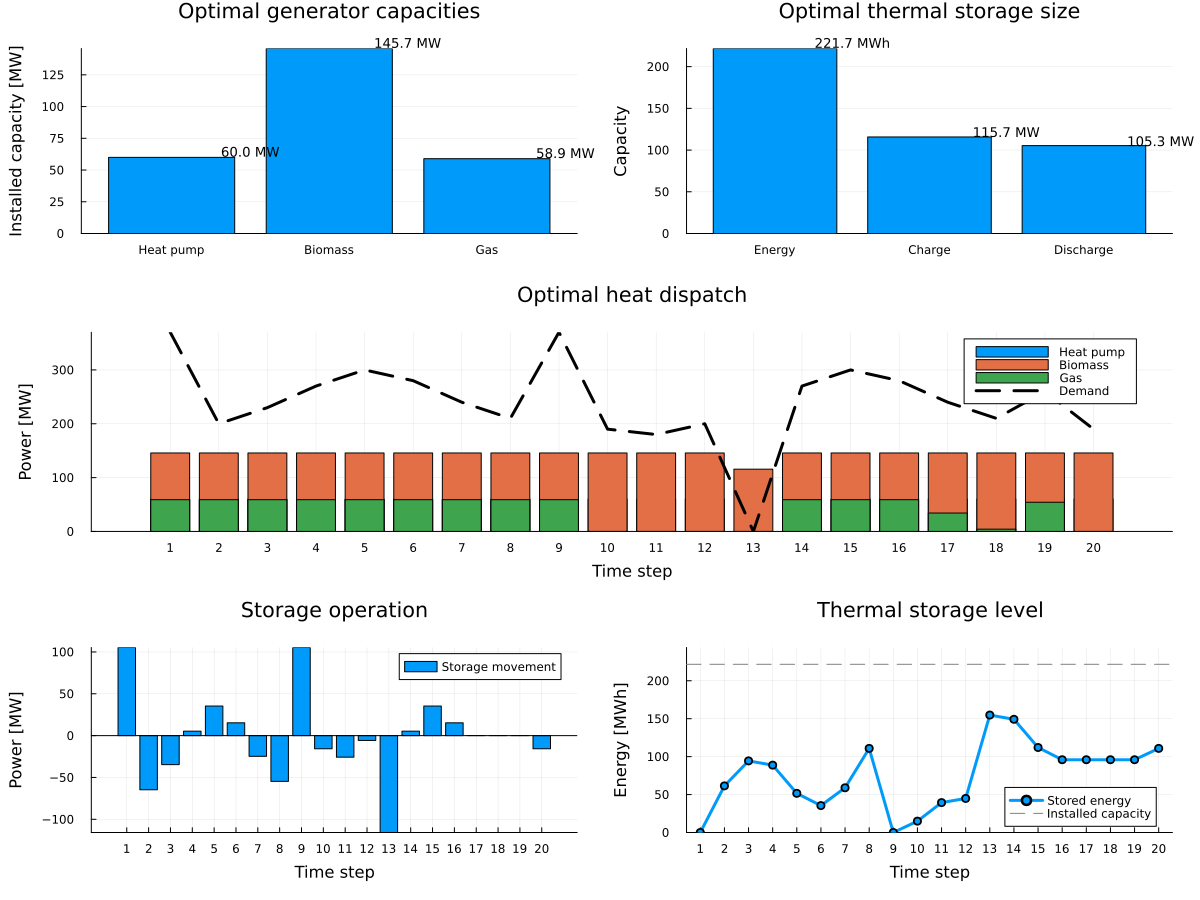

In [85]:
# RESULTS
x_result = value.(x)

hp      = x_result[1,:]
biomass = x_result[2,:]
gas     = x_result[3,:]

charge_result    = value.(charge)
discharge_result = value.(discharge)
storage_level    = value.(E)

m_result = value.(m)
Emax_result = value(E_max)
Pcharge_result = value(P_charge_max)
Pdischarge_result = value(P_discharge_max)

# 1. OPTIMAL INSTALLED CAPACITIES
p_capacity = bar(
    ["Heat pump", "Biomass", "Gas"],
    m_result,
    label = "",
    ylabel = "Installed capacity [MW]",
    title = "Optimal generator capacities",
    grid = :y,
    legend = false
)
# Werte über die Balken schreiben
for j in 1:3
    annotate!(
        p_capacity,
        j,
        m_result[j] + maximum(m_result)*0.03,
        text("$(round(m_result[j], digits=1)) MW", 9)
    )
end

# 2. OPTIMAL STORAGE SIZE
p_storage_size = bar(
    ["Energy", "Charge", "Discharge"],
    [Emax_result, Pcharge_result, Pdischarge_result],
    label = "",
    ylabel = "Capacity",
    title = "Optimal thermal storage size",
    grid = :y,
    legend = false
)

annotate!(
    p_storage_size,
    1,
    Emax_result * 1.03,
    text("$(round(Emax_result,digits=1)) MWh", 9)
)

annotate!(
    p_storage_size,
    2,
    Pcharge_result * 1.05,
    text("$(round(Pcharge_result,digits=1)) MW", 9)
)

annotate!(
    p_storage_size,
    3,
    Pdischarge_result * 1.05,
    text("$(round(Pdischarge_result,digits=1)) MW", 9)
)

# 3. OPTIMAL HEAT DISPATCH
generation = hcat(hp, biomass, gas)

p_dispatch = bar(
    1:N,
    generation,
    bar_position = :stack,
    labels = ["Heat pump" "Biomass" "Gas"],
    xlabel = "Time step",
    ylabel = "Power [MW]",
    title = "Optimal heat dispatch",
    xticks = 1:N,
    grid = true,
    legend = :topright
)

plot!(
    p_dispatch,
    1:N,
    d,
    label = "Demand",
    linewidth = 3,
    linestyle = :dash,
    color = :black
)

# 4. STORAGE OPERATION
storage_movement = discharge_result .- charge_result

p_storage_operation = bar(
    1:N,
    storage_movement,
    label = "Storage movement",
    xlabel = "Time step",
    ylabel = "Power [MW]",
    title = "Storage operation",
    xticks = 1:N,
    grid = true
)

hline!(
    p_storage_operation,
    [0],
    color = :black,
    linewidth = 1,
    label = ""
)

# 5. STORAGE LEVEL
p_storage_level = plot(
    1:N,
    storage_level,
    label = "Stored energy",
    xlabel = "Time step",
    ylabel = "Energy [MWh]",
    title = "Thermal storage level",
    linewidth = 3,
    marker = :circle,
    xticks = 1:N,
    ylim = (0, Emax_result * 1.1),
    grid = true
)

hline!(
    p_storage_level,
    [Emax_result],
    label = "Installed capacity",
    linestyle = :dash,
    color = :gray
)

# SHOW EVERYTHING
p = plot(
    p_capacity,
    p_storage_size,
    p_dispatch,
    p_storage_operation,
    p_storage_level,
    layout = @layout([
        a b
        c{0.35h}
        d e
    ]),
    size = (1200,900),
    margin = 5Plots.mm
)

display(p)

In [86]:
######################################
# TODO:
# - kapazitäten optimieren


In [87]:
MovementStorage = value.(discharge) - value.(charge)
InStorage   = value.(E)
StoreReserve = value.(storageReserve)
ymax = maximum(d)
ymin = minimum([minimum(MovementStorage),0])

p_power = plot(1:N,[value.(x[j,:]) for j in 1:3],labels=["Heat pump" "Biomass" "Gas"],xlabel="Time step",ylabel="Power [MW]",lw=2,title="Heat generation",ylim=(ymin,ymax), xticks=1:N, grid=true)
plot!(p_power, 1:N, MovementStorage,label="StorageMovement",lw=2,linestyle=:dot,color=:purple)
plot!(p_power, 1:N, d,label="Demand",lw=3,linestyle=:dash,color=:red)

p_storage = plot(1:N,InStorage,label="Stored energy",ylabel="Energy [MWh]",lw=2,title="Thermal storage level",linestyle=:dot,color=:purple, xticks=1:N,grid=true)   #,ylim=(ymin,ymax)

annotate!(p_storage, 2, 300,
    text("",
         9, :left)
)
p = plot(p_power,p_storage,layout=(1,2),size=(1000,400))
print("INTERPRET THE TWO GRAPHS, AS FOLLOWS:
MovementStorage > 0 <=> storage discharges <=> Energy decreasing
MovementStorage < 0 <=> storage charges  <=> Energy increasing"
)
display(p)


x_result = value.(x)

hp  = x_result[1,:]
bio = hp .+ x_result[2,:]
gas = bio .+ x_result[3,:]
total = gas .+ MovementStorage[:]
totalAvailability = gas .+ StoreReserve[:]
# tes = gas .+ x_result[4,:]

p1 = plot(1:N, hp, label="Heat pump", lw=2,title="MW in total",ylim=(0,ymax))
plot!(p1, 1:N, bio, label="+ Biomass", lw=2)
plot!(p1, 1:N, gas, label="+ Gas", lw=2)
plot!(p1, 1:N, total, label="+ MovementStorage", lw=2, linestyle=:dot,color=:purple)
# plot!(p1, 1:N, totalAvailability, label="Available Heat",lw=1,color=:grey)
plot!(p1, 1:N, d, label="Demand", lw=3, linestyle=:dash, color=:red)

# xlabel!(p1, "Time step")
ylabel!(p1, "Power [MW]")

p2 = plot(1:N, totalAvailability, label="Available Heat",lw=1,color=:grey)
plot!(p2,1:N,d,label="Demand",lw=3, linestyle=:dash,color=:red)
p12 = plot(p1,p2,layout=(1,2),size=(1000,400))

display(p12)

LoadError: UndefVarError: `storageReserve` not defined in `Main`
Suggestion: check for spelling errors or missing imports.